Quantium Virtual Internship - Retail Strategy and
Analytics - Task 1

This notebook contains data preprocessing, merging, analysis, and visualization to derive business insights from transactional datasets.

STEP 0: Setup

In [1]:
# Install
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 1: Load Data**

In this section, we load the dataset into our notebook and perform an initial inspection to understand its structure and contents.

In [ ]:
from google.colab import files
files.upload()

In [4]:
transactions = pd.read_excel("QVI_transaction_data.xlsx")
customers = pd.read_csv("QVI_purchase_behaviour.csv")

transactions.head()
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


**STEP 2: Understand Data**

In this section, we explore the dataset to understand its structure, variables, and overall content.

We aim to identify:
- The number of rows and columns
- Data types of each feature
- Key variables relevant to analysis
- Initial observations about the dataset

This step helps build a strong foundation before data cleaning and transformation.


In [5]:
transactions.info()
customers.info()

transactions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
m

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


**STEP 3: Data Cleaning**

Before performing any analysis, we clean the dataset to ensure accuracy and consistency.

In this step, we handle:
- Missing values
- Duplicate records
- Incorrect or inconsistent data types
- Outliers (if present)

Clean data is essential for reliable insights and accurate modeling.

3.1 Remove duplicates


In [6]:
transactions = transactions.drop_duplicates()
customers = customers.drop_duplicates()

3.2 Check missing values


In [7]:
transactions.isnull().sum()
customers.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


3.3 Fix Date Format

In [8]:
transactions['DATE'] = pd.to_datetime(transactions['DATE'], origin='1899-12-30', unit='D')

3.4 Remove Outliers

In [9]:
transactions['PROD_QTY'].describe()

,PROD_QTY
count,264835.000000
mean,1.907308
std,0.643655
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,200.000000


In [10]:
transactions = transactions[transactions['PROD_QTY'] < 20]

**STEP 4: Merge Data**

In this step, we combine multiple datasets to create a unified analytical view.

We perform joins based on common keys to ensure:
- No loss of important information
- Proper alignment of related variables
- A complete dataset for analysis

This merged dataset will be used for all further analysis.

In [11]:
data = pd.merge(transactions, customers, on="LYLTY_CARD_NBR")
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


**STEP 5: Feature Engineering**

Feature engineering is performed to create meaningful variables from existing data.

This helps improve analysis quality and extract deeper insights.

In this step, we:
- Create new derived features
- Transform existing variables
- Encode categorical variables
- Aggregate data where necessary

5.1 Extract PACK SIZE

In [12]:
data['PACK_SIZE'] = data['PROD_NAME'].str.extract('(\d+)g')
data['PACK_SIZE'] = pd.to_numeric(data['PACK_SIZE'])

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2993/1332943344.py:1: SyntaxWarning: invalid escape sequence '\d'
  data['PACK_SIZE'] = data['PROD_NAME'].str.extract('(\d+)g')


5.2 Extract BRAND

In [13]:
data['BRAND'] = data['PROD_NAME'].str.split().str[0]
data['BRAND'] = data['BRAND'].str.upper()

5.3 Create TOTAL SALES

In [14]:
data['TOTAL_SALES'] = data['PROD_QTY'] * data['TOT_SALES']

**STEP 6: Analysis**

In this section, we analyze the dataset to uncover patterns and trends.

We focus on:
- Understanding customer behavior
- Identifying key performance indicators (KPIs)
- Finding relationships between variables
- Generating business insights

This step bridges raw data and meaningful interpretation.

6.1 Sales by Customer Segment

In [15]:
segment_sales = data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOTAL_SALES'].sum().reset_index()
segment_sales

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES
0,MIDAGE SINGLES/COUPLES,Budget,69722.70
1,MIDAGE SINGLES/COUPLES,Mainstream,178914.75
2,MIDAGE SINGLES/COUPLES,Premium,114594.05
3,NEW FAMILIES,Budget,42431.05
4,NEW FAMILIES,Mainstream,33000.30
5,NEW FAMILIES,Premium,22250.50
6,OLDER FAMILIES,Budget,335506.35
7,OLDER FAMILIES,Mainstream,206358.05
8,OLDER FAMILIES,Premium,160803.10
9,OLDER SINGLES/COUPLES,Budget,269690.30


6.2 Average Spend

In [16]:
avg_spend = data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOTAL_SALES'].mean().reset_index()
avg_spend

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_SALES
0,MIDAGE SINGLES/COUPLES,Budget,13.888984
1,MIDAGE SINGLES/COUPLES,Mainstream,15.067774
2,MIDAGE SINGLES/COUPLES,Premium,13.947669
3,NEW FAMILIES,Budget,14.120150
4,NEW FAMILIES,Mainstream,14.193677
5,NEW FAMILIES,Premium,14.002832
6,OLDER FAMILIES,Budget,14.486457
7,OLDER FAMILIES,Mainstream,14.487367
8,OLDER FAMILIES,Premium,14.370250
9,OLDER SINGLES/COUPLES,Budget,14.651508


6.3 Purchase Frequency

In [17]:
freq = data.groupby('LYLTY_CARD_NBR').size().reset_index(name='transactions')
freq.head()

,LYLTY_CARD_NBR,transactions
0,1000,1
1,1002,1
2,1003,2
3,1004,1
4,1005,1


6.4 Units per Transaction

In [18]:
units = data.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PROD_QTY'].mean().reset_index()
units

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY
0,MIDAGE SINGLES/COUPLES,Budget,1.891633
1,MIDAGE SINGLES/COUPLES,Mainstream,1.911656
2,MIDAGE SINGLES/COUPLES,Premium,1.889727
3,NEW FAMILIES,Budget,1.853910
4,NEW FAMILIES,Mainstream,1.857634
5,NEW FAMILIES,Premium,1.860919
6,OLDER FAMILIES,Budget,1.945812
7,OLDER FAMILIES,Mainstream,1.948610
8,OLDER FAMILIES,Premium,1.945576
9,OLDER SINGLES/COUPLES,Budget,1.913403


6.5 Brand Preference

In [19]:
brand_pref = data.groupby(['BRAND','LIFESTAGE'])['TOTAL_SALES'].sum().reset_index()
brand_pref.sort_values(by='TOTAL_SALES', ascending=False).head(10)

,BRAND,LIFESTAGE,TOTAL_SALES
87,KETTLE,OLDER SINGLES/COUPLES,165922.0
88,KETTLE,RETIREES,150627.6
86,KETTLE,OLDER FAMILIES,131625.8
89,KETTLE,YOUNG FAMILIES,118777.4
90,KETTLE,YOUNG SINGLES/COUPLES,105430.2
45,DORITOS,OLDER SINGLES/COUPLES,84215.5
143,SMITHS,OLDER SINGLES/COUPLES,83397.2
142,SMITHS,OLDER FAMILIES,83291.1
46,DORITOS,RETIREES,76858.0
84,KETTLE,MIDAGE SINGLES/COUPLES,75845.0


6.6 Pack Size Preference

In [20]:
pack_pref = data.groupby(['PACK_SIZE','LIFESTAGE'])['TOTAL_SALES'].sum().reset_index()
pack_pref.head()

,PACK_SIZE,LIFESTAGE,TOTAL_SALES
0,70.0,MIDAGE SINGLES/COUPLES,1238.4
1,70.0,NEW FAMILIES,247.2
2,70.0,OLDER FAMILIES,2952.0
3,70.0,OLDER SINGLES/COUPLES,2683.2
4,70.0,RETIREES,2388.0


**STEP 7: Visualizations**

We use visual tools to better understand patterns in the data.

Visualizations help in:
- Identifying trends and distributions
- Comparing different groups
- Highlighting outliers or anomalies
- Communicating insights effectively

Common plots include bar charts, histograms, and line graphs.

Sales by Segment

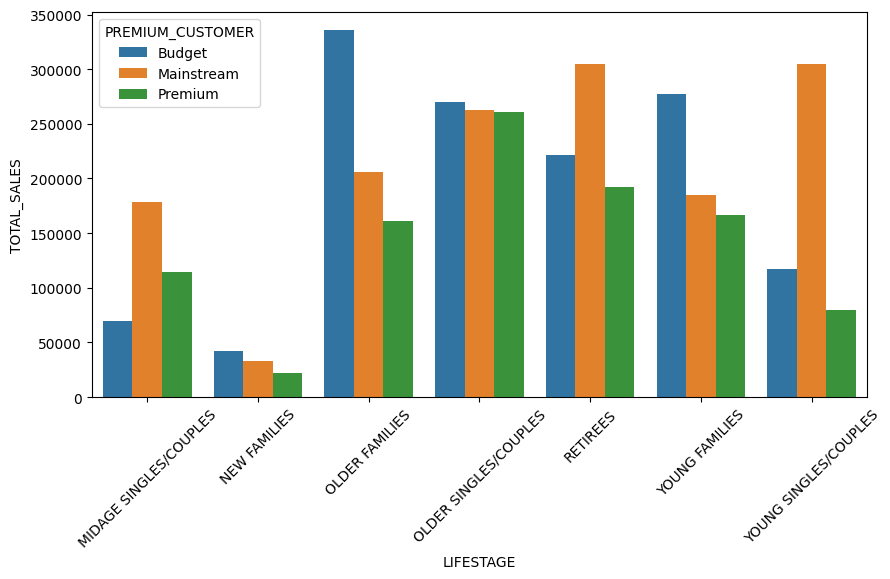

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(data=segment_sales, x='LIFESTAGE', y='TOTAL_SALES', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.show()

Pack Size Distribution

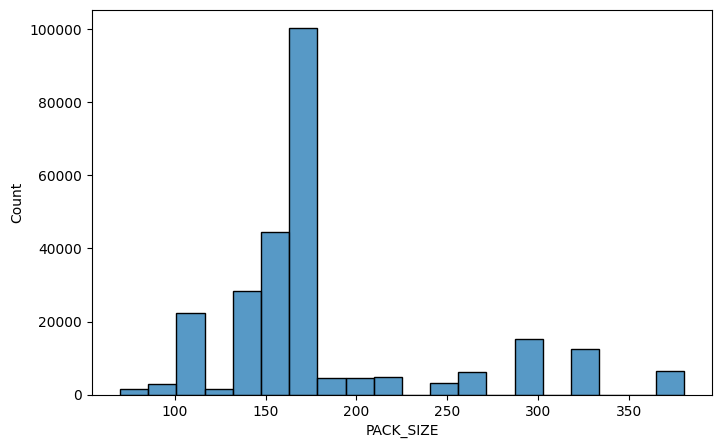

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data['PACK_SIZE'], bins=20)
plt.show()

**Conclusion**

In this task, we performed data loading, cleaning, merging, feature engineering, and exploratory analysis.

Key outcomes include:
- A cleaned and structured dataset ready for analysis
- Important business insights derived from the data
- Identification of key trends and patterns

These insights can be used to support data-driven decision-making.